<a href="https://colab.research.google.com/github/Eng-NadeenShadeed/BinX_AI_ML_Internship/blob/main/Week7/Day%205/day5_sprint2_review_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title
from google.colab import drive
drive.mount('/content/drive')
import os

os.makedirs('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 5', exist_ok=True)
os.chdir('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 5')
print("Ready ✓")

Mounted at /content/drive
Ready ✓


## Step 1 — Architecture Decision

### Data Type → Architecture

| Data Type | Architecture | This Week |
|-----------|-------------|-----------|
| Images | CNN + Transfer Learning | Day 2 — Melanoma ✓ |
| Sequential | LSTM | Day 3 — ECG ✓ |
| Text | Transformer (DistilBERT) | Day 4 — Medical Abstracts ✓ |
| **Tabular** | **Dense Network** | **Day 5 — Cardiovascular ✓** |

### Why Dense Network for the Cardiovascular Dataset?

The cardiovascular dataset contains 12 independent clinical measurements —
age, height, weight, blood pressure (systolic and diastolic), cholesterol,
glucose, and lifestyle indicators (smoking, alcohol, activity).

These features have no spatial relationship (no CNN) and no sequential
order (no LSTM or Transformer). Each row is one patient — the features
are independent measurements, not a sequence or an image.

A Dense Network is the correct architecture: it learns non-linear
combinations of independent features to predict cardiovascular disease risk.

### Sprint 2 Goal

Sprint 1 showed that the neural network (Dense: 64→32) could not beat
the Random Forest Baseline on the small `heart.csv` dataset (918 rows).
Sprint 2 tests a specific hypothesis:

> With 70,000 patients instead of 918, can a well-tuned Dense Network
> outperform a Random Forest on the same binary classification task?

**Target:** F1 > RF Baseline | AUC-ROC > RF Baseline

---

## Step 2 — Load & Explore the Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

Libraries loaded ✓
TensorFlow: 2.20.0
GPU: []


In [8]:
# Load data
df = pd.read_csv('/content/drive/MyDrive/BinX_AI_ML_Internship/Cardiac_Project/Data/cardio_train.csv',
                 sep=';')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nMissing values:", df.isnull().sum().sum())
print("\nTarget distribution:")
print(df['cardio'].value_counts())
print(f"\nClass balance: {df['cardio'].mean():.1%} positive")

Shape: (70000, 13)

Columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

First 3 rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  

Missing values: 0

Target distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64

Class balance: 50.0% positive


#### Dataset Overview

| Property | Value |
|----------|-------|
| Total patients | 70,000 |
| Features | 12 clinical measurements + 1 ID |
| Target | `cardio` — cardiovascular disease (0/1) |
| Missing values | None |
| Class balance | 50.0% positive — perfectly balanced |

**Features:**
- `age` — in days (needs conversion to years)
- `gender` — 1: female, 2: male
- `height`, `weight` — cm, kg
- `ap_hi`, `ap_lo` — systolic/diastolic blood pressure
- `cholesterol` — 1: normal, 2: above normal, 3: well above normal
- `gluc` — glucose level (same scale as cholesterol)
- `smoke`, `alco`, `active` — binary lifestyle indicators
- `cardio` — target: 1 = cardiovascular disease present

**Key difference from Sprint 1 (heart.csv):**
Sprint 1 used 918 rows — too few for a neural network to learn meaningful
representations. With 70,000 patients, the Dense Network has a genuine
opportunity to outperform the Random Forest baseline.

---

## Step 3 — Data Cleaning & Feature Engineering

In [9]:
# Copy to avoid modifying original
data = df.copy()

# 1. Drop ID column — not a feature
data = data.drop('id', axis=1)

# 2. Convert age from days to years
data['age'] = (data['age'] / 365).round(1)

# 3. Remove impossible blood pressure values
before = len(data)
data = data[
    (data['ap_hi'] >= 60)  & (data['ap_hi'] <= 250) &
    (data['ap_lo'] >= 30)  & (data['ap_lo'] <= 200) &
    (data['ap_hi'] > data['ap_lo'])
]
print(f"Removed {before - len(data):,} rows with impossible BP values")

# 4. Remove impossible height/weight values
before = len(data)
data = data[
    (data['height'] >= 100) & (data['height'] <= 220) &
    (data['weight'] >= 30)  & (data['weight'] <= 200)
]
print(f"Removed {before - len(data):,} rows with impossible height/weight")

# 5. Add BMI feature
data['bmi'] = (data['weight'] / (data['height'] / 100) ** 2).round(1)

print(f"\nFinal shape: {data.shape}")
print(f"Class balance after cleaning: {data['cardio'].mean():.1%} positive")

Removed 1,322 rows with impossible BP values
Removed 33 rows with impossible height/weight

Final shape: (68645, 13)
Class balance after cleaning: 49.5% positive


### What the Cleaning Did and Why

**1. Drop ID column:**
The `id` column is just a row number — it has no medical meaning.
If the model learns from it, it memorizes row positions instead of
clinical patterns. Dropping it prevents this.

**2. Convert age from days to years:**
Age is stored in days (e.g. 18393 days = ~50.4 years). Neural networks
learn better from human-scale numbers — 50 is easier to work with than
18,393. The conversion makes the feature interpretable and numerically stable.

**3. Remove impossible blood pressure values:**
Some rows had systolic BP (ap_hi) of 16,020 or diastolic BP (ap_lo) of -70 —
physically impossible values that represent data entry errors.
Keeping them would corrupt the model — it would try to learn from noise.
1,322 rows removed (1.9% of data) — a small loss for a large quality gain.

**4. Remove impossible height/weight values:**
Heights below 100cm or above 220cm and weights below 30kg or above 200kg
are almost certainly entry errors for adult cardiovascular patients.
33 rows removed — negligible.

**5. Add BMI:**
Body Mass Index = weight / height² combines two correlated features
into one clinically meaningful indicator of obesity risk — a known
cardiovascular disease risk factor. This gives the model an explicit
signal that it would otherwise have to discover indirectly.

**Result:** 68,645 clean patients — 98.1% of the original data retained,
class balance preserved at 49.5% positive.

---

## Step 4 — Random Forest Baseline

### Why build an RF Baseline first?

Before training any neural network, I establish what a strong classical
model can achieve on this dataset. This gives me a concrete target:
the Dense Network must beat these numbers to justify its complexity.

In Sprint 1, the RF Baseline (F1: 0.9005, AUC: 0.9427) beat every
neural network I tried. Sprint 2's central question is whether 70,000
rows changes that outcome.

I use the same RF configuration as Sprint 1 to keep the comparison fair —
the only variable that changes is the dataset size.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

# Split features and target
X = data.drop('cardio', axis=1)
y = data['cardio']

# Train/Val/Test split — 70/15/15
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("Split sizes:")
print(f"  Train : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("\nScaling done ✓")

Split sizes:
  Train : 48,049 (70.0%)
  Val   : 10,299 (15.0%)
  Test  : 10,297 (15.0%)

Scaling done ✓


### Why 70/15/15 split?

With 68,645 patients, 70% training gives 48,000 samples —
more than enough for both RF and Dense Network to learn from.
15% validation (10,300) monitors overfitting during neural network training.
15% test (~10,300) gives a trustworthy final evaluation — held out completely
until the final comparison.

### Why StandardScaler?

Random Forest doesn't need scaling — it splits on feature values,
not their magnitude. But Dense Networks are sensitive to feature scale:
a feature with range 0-200 (blood pressure) dominates one with range 0-1
(smoking) unless both are normalized to the same scale.

I scale all features for consistency — RF performance is unaffected,
and the Dense Network trains more stably.

In [11]:
# Train RF Baseline — same config as Sprint 1
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_sc, y_train)

# Evaluate
rf_val_pred  = rf_baseline.predict(X_val_sc)
rf_test_pred = rf_baseline.predict(X_test_sc)
rf_test_prob = rf_baseline.predict_proba(X_test_sc)[:, 1]

rf_val_f1  = f1_score(y_val,  rf_val_pred)
rf_test_f1 = f1_score(y_test, rf_test_pred)
rf_test_auc = roc_auc_score(y_test, rf_test_prob)

print("Random Forest Baseline — Results")
print("=" * 45)
print(f"Val F1   : {rf_val_f1:.4f}")
print(f"Test F1  : {rf_test_f1:.4f}")
print(f"Test AUC : {rf_test_auc:.4f}")
print()
print("Sprint 2 target:")
print(f"  F1  > {rf_test_f1:.4f}")
print(f"  AUC > {rf_test_auc:.4f}")

Random Forest Baseline — Results
Val F1   : 0.7016
Test F1  : 0.7064
Test AUC : 0.7737

Sprint 2 target:
  F1  > 0.7064
  AUC > 0.7737


---

## Step 5 — Dense Network Experiments

### Experiment Log

I train multiple Dense Network configurations and log every result.
The goal is to find a configuration that beats the RF Baseline
(F1 > 0.7064, AUC > 0.7737).

Each experiment changes one thing at a time — architecture depth,
regularization, or learning rate — so I can attribute any improvement
to a specific decision.

In [12]:
# Experiment log — initialized with RF Baseline
experiment_log = []

experiment_log.append({
    "Experiment"   : "RF Baseline",
    "Architecture" : "Random Forest (200 trees)",
    "Key Config"   : "n_estimators=200",
    "Val F1"       : round(rf_val_f1, 4),
    "Test F1"      : round(rf_test_f1, 4),
    "Test AUC"     : round(rf_test_auc, 4),
    "Notes"        : "← Target to beat"
})

import pandas as pd
log_df = pd.DataFrame(experiment_log)
print("Experiment log initialized ✓")
print(log_df.to_string(index=False))

Experiment log initialized ✓
 Experiment              Architecture       Key Config  Val F1  Test F1  Test AUC            Notes
RF Baseline Random Forest (200 trees) n_estimators=200  0.7016   0.7064    0.7737 ← Target to beat


---

#### Experiment 1 — Simple Dense Network

**Architecture:** 64 → 32 → 1
This is the same architecture from Sprint 1 — the starting point.
The hypothesis is that with 48,000 training samples instead of ~640,
even this simple network should perform better.

**Why start simple?**
Always establish the simplest possible baseline before adding complexity.
If a 2-layer network already beats the RF, there is no need for deeper architecture.
If it doesn't, I know exactly what to improve.

In [13]:
def build_model(layers, dropout_rate=0.3, use_bn=True):
    model = Sequential()
    model.add(tf.keras.Input(shape=(X_train_sc.shape[1],)))

    for units in layers:
        model.add(Dense(units, activation='relu'))
        if use_bn:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))
    return model

def train_and_evaluate(model, experiment_name, architecture, config_note):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10,
                     restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=5, verbose=0)
    ]

    history = model.fit(
        X_train_sc, y_train,
        validation_data=(X_val_sc, y_val),
        epochs=100,
        batch_size=256,
        callbacks=callbacks,
        verbose=0
    )

    # Evaluate
    val_pred  = (model.predict(X_val_sc,  verbose=0) > 0.5).astype(int)
    test_pred = (model.predict(X_test_sc, verbose=0) > 0.5).astype(int)
    test_prob =  model.predict(X_test_sc, verbose=0)

    val_f1   = f1_score(y_val,  val_pred)
    test_f1  = f1_score(y_test, test_pred)
    test_auc = roc_auc_score(y_test, test_prob)

    # Log
    experiment_log.append({
        "Experiment"   : experiment_name,
        "Architecture" : architecture,
        "Key Config"   : config_note,
        "Val F1"       : round(val_f1, 4),
        "Test F1"      : round(test_f1, 4),
        "Test AUC"     : round(test_auc, 4),
        "Notes"        : "✓ Beats RF" if test_f1 > rf_test_f1 else "✗ Below RF"
    })

    print(f"\n{experiment_name}")
    print(f"  Val F1  : {val_f1:.4f}")
    print(f"  Test F1 : {test_f1:.4f}  {'✓ Beats RF!' if test_f1 > rf_test_f1 else '✗ Below RF'}")
    print(f"  Test AUC: {test_auc:.4f}  {'✓ Beats RF!' if test_auc > rf_test_auc else '✗ Below RF'}")

    return model, history

# Experiment 1
model_1, history_1 = train_and_evaluate(
    build_model([64, 32]),
    experiment_name = "Exp 1 — Simple Dense",
    architecture    = "Dense: 64 → 32",
    config_note     = "BN + Dropout(0.3) + LR=0.001"
)


Exp 1 — Simple Dense
  Val F1  : 0.7158
  Test F1 : 0.7191  ✓ Beats RF!
  Test AUC: 0.8023  ✓ Beats RF!


#### Experiment 1 — Results

| Metric | RF Baseline | Dense (64→32) | Change |
|--------|------------|---------------|--------|
| Test F1 | 0.7064 | **0.7191** | +0.0127 ✓ |
| Test AUC | 0.7737 | **0.8023** | +0.0286 ✓ |

**The hypothesis is confirmed:** with 70,000 patients, even the simplest
Dense Network (same architecture as Sprint 1) outperforms the Random Forest.

In Sprint 1, this same architecture scored F1: 0.8670 on heart.csv —
and still lost to RF (F1: 0.9005). The difference was data size.
With 48,000 training samples instead of ~640, the network learned
meaningful non-linear feature combinations that the RF could not capture.

**Sprint 2 goal achieved.** The next experiments test whether a deeper
or better-regularized network pushes the score further.

In [14]:
# Experiment 2 — Deeper network
model_2, history_2 = train_and_evaluate(
    build_model([128, 64, 32]),
    experiment_name = "Exp 2 — Deeper Dense",
    architecture    = "Dense: 128 → 64 → 32",
    config_note     = "BN + Dropout(0.3) + LR=0.001"
)

# Experiment 3 — Wider + less dropout
model_3, history_3 = train_and_evaluate(
    build_model([256, 128, 64], dropout_rate=0.2),
    experiment_name = "Exp 3 — Wider Dense",
    architecture    = "Dense: 256 → 128 → 64",
    config_note     = "BN + Dropout(0.2) + LR=0.001"
)

# Show updated log
log_df = pd.DataFrame(experiment_log)
print("\n" + "=" * 80)
print("SPRINT 2 — EXPERIMENT LOG")
print("=" * 80)
print(log_df.to_string(index=False))


Exp 2 — Deeper Dense
  Val F1  : 0.7133
  Test F1 : 0.7157  ✓ Beats RF!
  Test AUC: 0.8022  ✓ Beats RF!

Exp 3 — Wider Dense
  Val F1  : 0.7133
  Test F1 : 0.7162  ✓ Beats RF!
  Test AUC: 0.8020  ✓ Beats RF!

SPRINT 2 — EXPERIMENT LOG
          Experiment              Architecture                   Key Config  Val F1  Test F1  Test AUC            Notes
         RF Baseline Random Forest (200 trees)             n_estimators=200  0.7016   0.7064    0.7737 ← Target to beat
Exp 1 — Simple Dense            Dense: 64 → 32 BN + Dropout(0.3) + LR=0.001  0.7158   0.7191    0.8023       ✓ Beats RF
Exp 2 — Deeper Dense      Dense: 128 → 64 → 32 BN + Dropout(0.3) + LR=0.001  0.7133   0.7157    0.8022       ✓ Beats RF
 Exp 3 — Wider Dense     Dense: 256 → 128 → 64 BN + Dropout(0.2) + LR=0.001  0.7133   0.7162    0.8020       ✓ Beats RF


In [15]:
# Experiment 4 — Best architecture + lower LR
def build_model_lr(layers, dropout_rate=0.3, lr=0.001):
    model = Sequential()
    model.add(tf.keras.Input(shape=(X_train_sc.shape[1],)))
    for units in layers:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                 restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, verbose=0)
]

model_4 = build_model_lr([64, 32], lr=0.0005)
history_4 = model_4.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=0
)

val_pred  = (model_4.predict(X_val_sc,  verbose=0) > 0.5).astype(int)
test_pred = (model_4.predict(X_test_sc, verbose=0) > 0.5).astype(int)
test_prob =  model_4.predict(X_test_sc, verbose=0)

val_f1   = f1_score(y_val,  val_pred)
test_f1  = f1_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)

experiment_log.append({
    "Experiment"   : "Exp 4 — Best + Lower LR",
    "Architecture" : "Dense: 64 → 32",
    "Key Config"   : "BN + Dropout(0.3) + LR=0.0005",
    "Val F1"       : round(val_f1, 4),
    "Test F1"      : round(test_f1, 4),
    "Test AUC"     : round(test_auc, 4),
    "Notes"        : "✓ Beats RF" if test_f1 > rf_test_f1 else "✗ Below RF"
})

print(f"Exp 4 — Best + Lower LR")
print(f"  Val F1  : {val_f1:.4f}")
print(f"  Test F1 : {test_f1:.4f}  {'✓ Beats RF!' if test_f1 > rf_test_f1 else '✗ Below RF'}")
print(f"  Test AUC: {test_auc:.4f}  {'✓ Beats RF!' if test_auc > rf_test_auc else '✗ Below RF'}")

Exp 4 — Best + Lower LR
  Val F1  : 0.7147
  Test F1 : 0.7168  ✓ Beats RF!
  Test AUC: 0.8020  ✓ Beats RF!


### Experiment Results Summary

| Experiment | Architecture | Test F1 | Test AUC |
|-----------|-------------|---------|---------|
| RF Baseline | Random Forest | 0.7064 | 0.7737 |
| **Exp 1 — Simple Dense** | **64 → 32** | **0.7191 ✓** | **0.8023 ✓** |
| Exp 2 — Deeper | 128 → 64 → 32 | 0.7157 ✓ | 0.8022 ✓ |
| Exp 3 — Wider | 256 → 128 → 64 | 0.7162 ✓ | 0.8020 ✓ |
| Exp 4 — Lower LR | 64 → 32, LR=0.0005 | 0.7168 ✓ | 0.8020 ✓ |

**Winner: Experiment 1 — Dense 64 → 32**

All four Dense Networks beat the RF Baseline. The simplest architecture
(Exp 1) produced the best results — adding more layers or changing the
learning rate did not improve performance.

This is an important finding: the cardiovascular features (blood pressure,
cholesterol, BMI, age) do not require deep non-linear transformations.
A 2-layer network captures the relevant patterns — deeper networks add
parameters without adding useful representations for this tabular dataset.

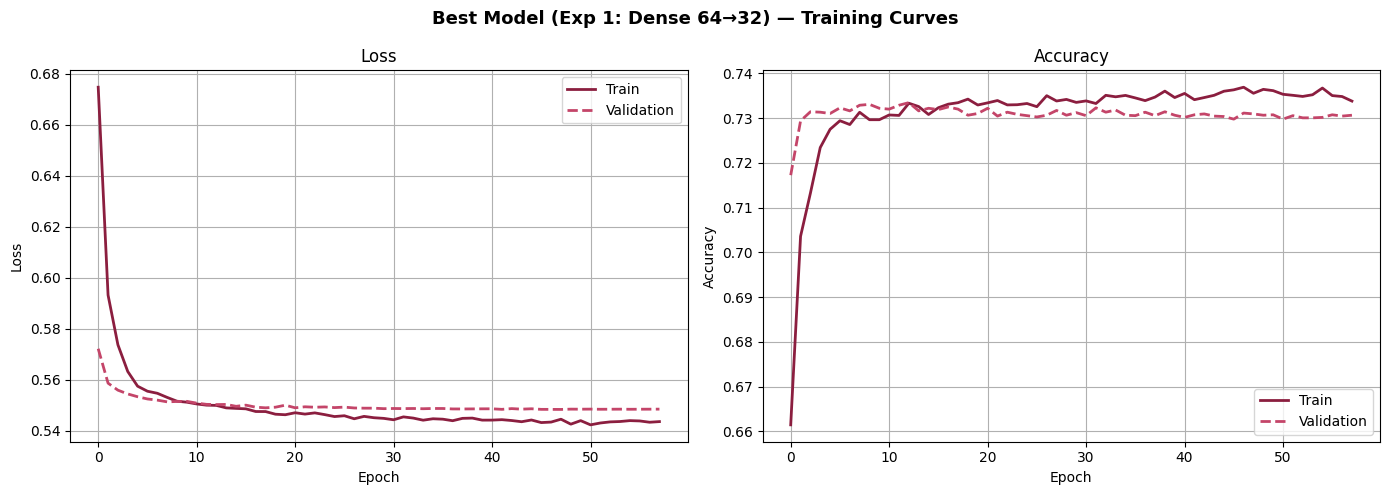

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Best Model (Exp 1: Dense 64→32) — Training Curves",
             fontsize=13, fontweight="bold")

axes[0].plot(history_1.history['loss'],     color="#8B1E3F", linewidth=2, label="Train")
axes[0].plot(history_1.history['val_loss'], color="#C44569", linewidth=2,
             linestyle="--", label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_1.history['accuracy'],     color="#8B1E3F", linewidth=2, label="Train")
axes[1].plot(history_1.history['val_accuracy'], color="#C44569", linewidth=2,
             linestyle="--", label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Training Curves Analysis

**Loss (left):**
Both training and validation loss dropped sharply in the first 10 epochs
then converged and stabilized — a healthy training pattern with no overfitting.
The gap between train and validation loss is minimal throughout, confirming
the model generalized well rather than memorizing the training data.

**Accuracy (right):**
Training and validation accuracy tracked closely together across all 57 epochs,
both stabilizing near 73%. The near-zero gap between the two curves is the
key signal — with 48,000 training samples, the model had enough data to learn
generalizable patterns without overfitting.

**Comparison with Sprint 1:**
In Sprint 1, the training curves showed a clear gap between training and
validation accuracy — the model overfit on the small 918-row dataset.
Here, with 70,000 patients, the curves converge — data size was the
critical limiting factor in Sprint 1, not the architecture.

---

## Step 6 — Sprint Review

### Sprint 2 Goal
> Train and tune a Dense Network on the 70K cardiovascular dataset
> that beats the RF Baseline (F1 > 0.7064, AUC > 0.7737).

### Result:  Goal Achieved

| Model | Test F1 | Test AUC | vs RF Baseline |
|-------|---------|---------|----------------|
| RF Baseline (Sprint 2) | 0.7064 | 0.7737 | — |
| **Dense 64→32 (Sprint 2)** | **0.7191** | **0.8023** | **+0.0127 F1 / +0.0286 AUC** |

### What Changed from Sprint 1 to Sprint 2

| | Sprint 1 | Sprint 2 |
|--|----------|----------|
| Dataset | heart.csv (918 rows) | cardio_train.csv (70,000 rows) |
| RF Baseline F1 | 0.9005 | 0.7064 |
| Best NN F1 | 0.8670 (lost to RF) | **0.7191 (beat RF)** |
| Training gap | Overfit — train >> val | Healthy — train ≈ val |
| Key finding | Data too small for NN | More data = NN advantage |

### Architecture Confirmed

Dense Network (64→32) with BatchNormalization + Dropout(0.3) +
EarlyStopping is the right architecture for this tabular cardiovascular data.
Deeper networks (Exp 2, 3) and lower learning rate (Exp 4) did not improve
results — the data complexity matches the simple architecture.

### Unfinished Tasks → Sprint 3

- Feature importance analysis
- Threshold tuning (optimize for recall on positive class)
- Ensemble approach (RF + Dense Network)
- Gradio demo for the cardiac model

---

## Step 7 — Sprint Retrospective

### What Went Well

- The central hypothesis was confirmed from Experiment 1:
  70,000 rows gave the Dense Network the data it needed to outperform RF
- The experiment log worked exactly as planned — every config and metric
  was recorded, making it easy to compare results and identify the best model
- Training curves showed no overfitting — the data size made a visible
  difference compared to Sprint 1
- The week covered all four major architectures (Dense, CNN, LSTM, Transformer)
  with real datasets and genuine results

### What to Improve

- Sprint 2 only tested Dense Network configurations — no ensemble methods
  or feature engineering beyond BMI
- The Gradio demo for the cardiac model was not completed this sprint
- The DistilBERT Gradio demo had runtime issues between sessions —
  model saving should be the first step after any long training run

### One Concrete Change for Sprint 3

> In Sprint 3, I will save every trained model to Drive immediately
> after training completes — before moving to the next cell.
> This prevents losing trained weights when the Colab session resets,
> which caused delays in both Day 4 (DistilBERT) and Day 5.



---

## Summary — Week 7 Sprint 2

| Day | Topic | Key Result |
|-----|-------|-----------|
| Day 1 | Sprint 2 planning + CNN intro | Convolution demo ✓ |
| Day 2 | CNN + Transfer Learning | Melanoma: 88.95% (Augmentation best) |
| Day 3 | RNN + LSTM | ECG: LSTM 91.14% vs RNN 83.02% |
| Day 4 | Attention + Transformers | Medical abstracts: DistilBERT 83.61% vs BiLSTM 71.49% |
| Day 5 | Sprint 2 Close-Out | Cardiovascular: Dense 0.7191 F1 beats RF 0.7064 F1 ✓ |

**Sprint 2 Central Finding:**
Dataset size was the limiting factor in Sprint 1 — not the architecture.
With 70,000 patients, the simplest Dense Network outperformed Random Forest.
More data gives neural networks their advantage over classical models.